In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import pyarrow
from pathlib import Path
import scipy
from scipy import stats
from scipy.stats import pearsonr, spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

#Desactivar notacion científica
pd.set_option('display.float_format', '{:.2f}'.format)

In [124]:
from matplotlib.ticker import PercentFormatter

sns.set_theme(
    style="whitegrid",
    context="notebook"
)
#path de reports/graphics
GRAPHICS_PATH = Path("../reports/graphics")
GRAPHICS_PATH.mkdir(parents=True, exist_ok=True)

In [125]:
df = pd.read_parquet("../data/processed/df_analysis.parquet")
df_event_session = pd.read_parquet("../data/processed/df_event_session.parquet")

## Analisis de Producto

#### Preparación de datos

In [237]:
df_event_session["is_add_to_cart"] = df_event_session["event"].eq("cart")
df_event_session["is_remove_from_cart"] = df_event_session["event"].eq("remove_from_cart")
df_event_session["is_purchase"] = df_event_session["event"].eq("purchase")
df_event_session["is_view"] = df_event_session["event"].eq("view")

df_products_session = df_event_session.copy()

Debido a la naturaleza de los propios eventos view, cart y purchase, y de como se encuentran en cada sesion analítica no se generará un funnel de conversion ya que presentaria datos efectivamente distorsionados ya que:
- Un view parece representar una exposición.
- Un purchase puede representar múltiples unidades o eventos del mismo producto.
- Una compra puede ocurrir en otra analytical_session distinta de la vista inicial.
Por tanto, la solución más defendible planteada es trabajar a nivel de producto dentro de sesión, usando indicadores binarios de engagement sobre el producto y relacionar el engage con el evento compra.

In [ ]:
#Solo es revenue si proviene de un evento purchase
df_products_session["purchase_revenue"] = df_products_session["price"].where(df_products_session["is_purchase"], 0)
#dataset de productos a nivel sesion y producto
product_session = (
    df_products_session.groupby(["analytical_session", "product_id"], as_index=False)
    .agg(
        has_view=("is_view", "max"),
        has_cart=("is_add_to_cart", "max"),
        has_purchase=("is_purchase", "max"),
        purchase_event_count=("is_purchase", "sum"),
        revenue=("purchase_revenue", "sum"),
    )
)

In [ ]:
#Variable engage para determinar si el producto tiene interaccion en la sesion
product_session["is_product_engaged"] = (product_session[["has_view", "has_cart", "has_purchase"]].any(axis=1))

In [ ]:
#Dataset de metricas de producto
product_metrics = (
    product_session
    .groupby("product_id", as_index=False)
    .agg(
        engaged_sessions=("is_product_engaged", "sum"),
        view_sessions=("has_view", "sum"),
        cart_sessions=("has_cart", "sum"),
        purchase_sessions=("has_purchase", "sum"),
        purchase_events=("purchase_event_count", "sum"),
        revenue=("revenue", "sum"),
    )
    .assign(
        product_session_purchase_rate=lambda data: (
            data["purchase_sessions"] / data["engaged_sessions"]
        ),
        observed_view_coverage=lambda data: (
            data["view_sessions"] / data["engaged_sessions"]
        ),
        revenue_per_engaged_session=lambda data: (
            data["revenue"] / data["engaged_sessions"]
        ),
    )
    .replace([float("inf"), float("-inf")], None)
)

#### Product popularity

<Axes: xlabel='product_id'>

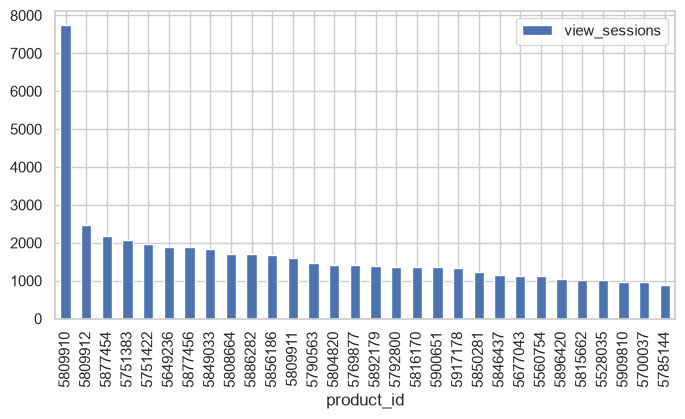

In [130]:
product_metrics_views = product_metrics[['product_id','view_sessions']].nlargest(30,'view_sessions').sort_values(by='view_sessions',ascending=False)
product_metrics_views.plot(kind='bar', x='product_id', y='view_sessions', figsize=(8, 4))

In [131]:
product_metrics[product_metrics.product_id.eq(5809910)].index.start

16807

In [132]:
top1_loc = product_metrics.sort_values(by='revenue',ascending=False).index.get_loc(16807) + 1
top1_loc

2

El producto *5809910* parece ser **el más popular con mucha** diferencia respecto al segundo y además se encuentra en **segunda posicion en revenue total.**

#### Revenue total 

<Axes: xlabel='product_id'>

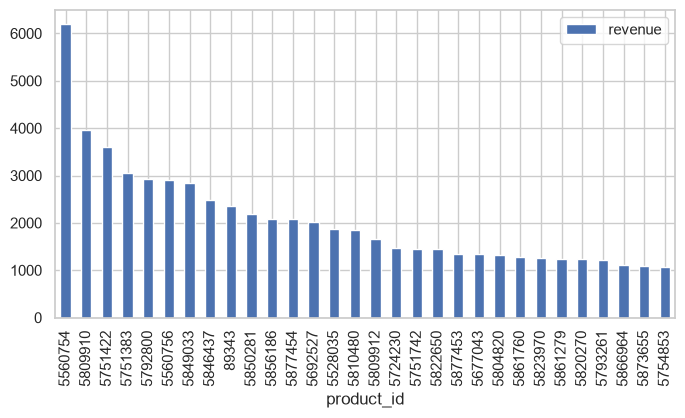

In [133]:
product_engaged_plot = (
    product_metrics[['product_id','revenue']]
    .nlargest(30,'revenue')
    .sort_values(by='revenue',ascending=False)
)
product_engaged_plot.plot(kind='bar', x='product_id', y='revenue', figsize=(8, 4))


Concentracion de revenue

In [134]:
product_sorted = product_metrics.sort_values(
    "revenue",
    ascending=False
)

total_revenue = product_sorted["revenue"].sum()

percentages = [0.01, 0.05, 0.10, 0.20]

for p in percentages:
    n = int(len(product_sorted) * p)
    
    top_revenue = product_sorted.iloc[:n]["revenue"].sum()
    revenue_share = top_revenue / total_revenue
    
    print(f"Top {p:.0%}: {revenue_share:.1%} del revenue")

Top 1%: 33.4% del revenue
Top 5%: 59.2% del revenue
Top 10%: 72.7% del revenue
Top 20%: 86.6% del revenue


### Insight 7: Alta concentracion de revenue en baja cantidad de productos
- **Alta concentración de ventas:** El producto **5809910** destaca como el más popular con mucha diferencia y ocupa además la **2.ª posición en revenue**.

- El revenue presenta una elevada concentración en un reducido número de productos: el **20% de los productos genera el 86,6% de los ingresos**, mientras que el 1% concentra ya el 33,4%. Esto indica una fuerte dependencia de los productos líderes y un amplio catálogo de baja contribución económica.

Recomendaciones: Priorizar la gestión y disponibilidad de los productos líderes, especialmente los que combinan alto revenue y popularidad, asegurando stock y visibilidad. Paralelamente, identificar productos del long tail con potencial para impulsar su conversión y reducir progresivamente la dependencia de los best sellers.


### Product performance

In [135]:
product_metrics.revenue.describe(percentiles=[0.75, 0.9, 0.95, 0.99])

count   45327.00
mean       13.71
std        73.06
min         0.00
75%         9.54
90%        27.63
95%        51.04
99%       177.54
max      6192.88
Name: revenue, dtype: float64

In [136]:
plot_data = product_metrics[
    product_metrics["engaged_sessions"].gt(0)
    & product_metrics["revenue"].gt(0)
    & product_metrics["product_session_purchase_rate"].between(0, 1)
].copy()

In [ ]:
#filtros de engagement por sesion, revenue y purchase rate para evitar datos anomalos
engagement_cutoff = plot_data["engaged_sessions"].quantile(0.75)
revenue_cutoff = plot_data["revenue"].quantile(0.75)
purchases_cutoff = plot_data["purchase_sessions"].quantile(0.75)

#aplicamos filtros
plot_data = plot_data[
    (plot_data["engaged_sessions"] >= engagement_cutoff)
    | (plot_data["revenue"] >= revenue_cutoff)
    | (plot_data["purchase_sessions"] >= purchases_cutoff)
]

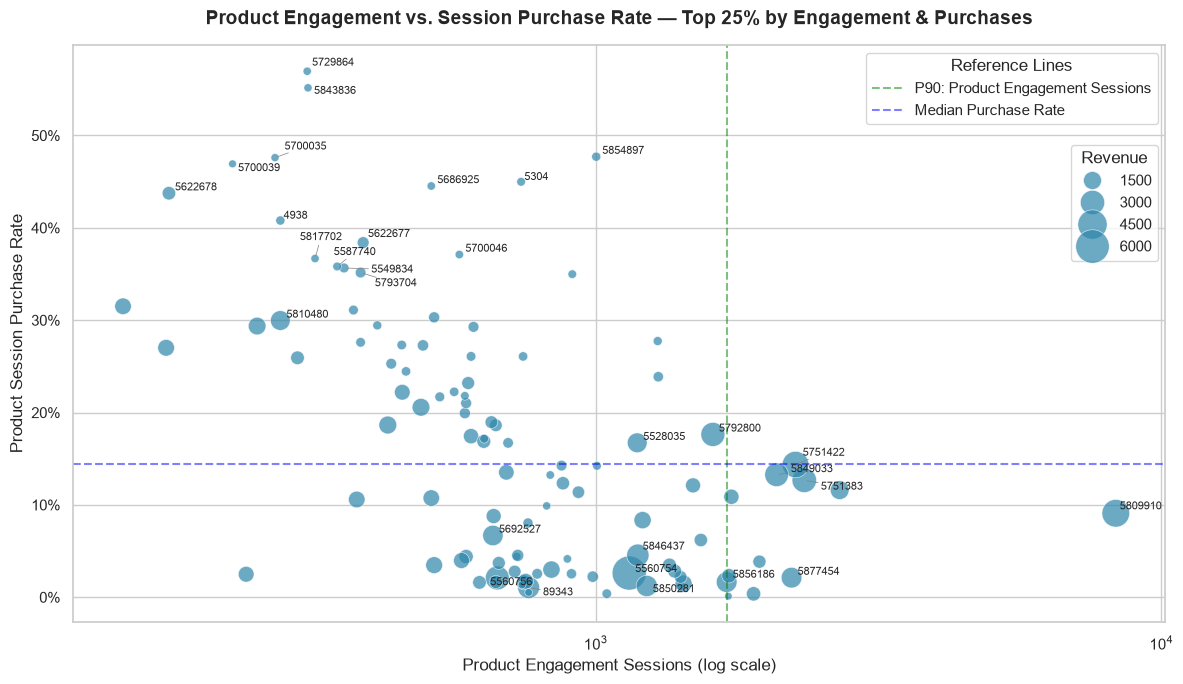

In [188]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=plot_data,
    x="engaged_sessions",
    y="product_session_purchase_rate",
    size="revenue",
    sizes=(30, 600),
    alpha=0.7,
    color="#2E86AB",
    legend="brief",
    ax=ax,
)
#escala del eje X logaritmica
ax.set_xscale("log")

#titulos
ax.set_title("Product Engagement vs. Session Purchase Rate — Top 25% by Engagement & Purchases", fontsize=14, fontweight="bold", pad=15)
ax.set(xlabel="Product Engagement Sessions (log scale)", ylabel="Product Session Purchase Rate",)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.get_legend().set_title("Revenue")

#Productos con label en el scatter
from adjustText import adjust_text
labels = pd.concat([plot_data.nlargest(15, "revenue"),plot_data.nlargest(15, "product_session_purchase_rate"),]).drop_duplicates("product_id")

texts = []
for product_id, engagement, purchase_rate in zip(
    labels["product_id"],
    labels["engaged_sessions"],
    labels["product_session_purchase_rate"],
):
    texts.append(ax.text(engagement, purchase_rate, str(product_id).removesuffix(".0"), fontsize=8,))

adjust_text(
    texts,
    ax=ax,
    only_move={"points": "xy", "text": "xy"},
    arrowprops={
        "arrowstyle": "-",
        "color": "gray",
        "linewidth": 0.5,
    },
)

#lineas de la leyenda
rate_cutoff = plot_data.product_session_purchase_rate.std()
engagement_cutoff_line = plot_data.engaged_sessions.quantile(0.90)
engagement_line = ax.axvline(engagement_cutoff_line, color="green", alpha=0.5, linestyle="--", label="P90: Product Engagement Sessions")
purchases_line = ax.axhline(rate_cutoff, color="blue", alpha=0.5, linestyle="--", label="Median Purchase Rate")

#leyendas
revenue_legend = ax.get_legend()
revenue_legend.set_bbox_to_anchor((1, 0.84),transform=ax.transAxes,)
revenue_legend.set_title("Revenue")
ax.add_artist(revenue_legend)

ax.legend(handles=[engagement_line, purchases_line], title="Reference Lines", loc="upper right",)

plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "product_engagement_vs_purchase_rate.png", dpi=300, bbox_inches="tight")
plt.show()

Tabla para comparar productos destacados (Top 15 Revenue + Top 15 Purchase Rate)

In [ ]:
labels_table = labels.copy()
labels_table['product_price'] = labels_table['revenue'] / labels_table['purchase_events']
labels_table = labels_table[["product_id", "engaged_sessions", "product_session_purchase_rate", "product_price", "revenue"]] \
.sort_values("product_session_purchase_rate", ascending=False)

In [178]:
labels_table

,product_id,engaged_sessions,product_session_purchase_rate,product_price,revenue
8232,5729864,309,0.57,0.41,71.78
24787,5843836,310,0.55,0.38,64.97
28178,5854897,1002,0.48,0.32,153.64
6642,5700035,271,0.48,0.39,52.01
6646,5700039,228,0.47,0.29,31.46
314,5304,738,0.45,0.32,108.37
5386,5686925,512,0.45,0.35,80.79
3054,5622678,176,0.44,9.09,708.82
240,4938,277,0.41,1.42,161.77
3053,5622677,388,0.38,3.14,468.12


Pearson y spearman para purchase_rate y price

In [175]:
product_metrics['product_price'] = product_metrics['revenue'] / product_metrics['purchase_events']
spearman_correlation = product_metrics[
    "product_session_purchase_rate"
].corr(
    product_metrics["product_price"],
    method="spearman",
)

pearson_correlation = product_metrics[
    "product_session_purchase_rate"
].corr(
    product_metrics["product_price"],
    method="pearson",
)

print(f"Spearman: {spearman_correlation:.2f}")
print(f"Pearson: {pearson_correlation:.2f}")

Spearman: -0.41
Pearson: -0.20


El precio presenta una relación negativa con la tasa de compra por sesión: los productos más caros tienden a comprar-se relativamente menos.
La relación monotónica es moderada (Spearman = -0.41) y más intensa que la relación lineal (Pearson = -0.20). Esto sugiere que el efecto del precio no es uniforme ni estrictamente lineal: existen rangos de precio y otros factores como categoría, marca o tipo de producto que probablemente condicionan la sensibilidad al precio.

In [ ]:
#Comprovacion de existencia en el mercado de los top 15 productos con purchase rate mas alto para los meses del analisis
df.loc[df["product_id"].isin(top15_purchase_rate)] \
    .groupby(["product_id", "month"]) \
    .agg(purchase_events=("is_purchase", "sum")) \
    .unstack("month", fill_value=0)

purchase_events                                  
month             December February January November October
product_id                                                  
5622677                 25       20      39       35      30
5622678                 12       14      22       15      15
5705002                  6        8      25       16      21
5787965                  3        2       5        4       1
5798928                  3        9      10        9       7
5809858                  1        5       4        1       3
5809860                  3        6       3        7       3
5810479                  4        5       7       10       2
5845327                  2        9      12       14       3
5855333                 15       17      19       20       7
5867090                  5        2       7       10       2
5867091                  5        5       8       10       6
5868470                  8        2       1        4       8
5889300                 14       28      33       18       6
5901858                  8       18      14        3       0

### Insight 8: Product performance overview
- **Gigantes dormidos (alto revenue)**: Los productos con alto revenue total como el *89343, 5560756 o 5560754* poseen un purchase rate(PR) por sesion bastante bajo **(1-5%)**, mas interaccion (visitas, carrito y/o compras) y precio de producto mas elevado. Esto se puede explicar debido a que los productos mas caros normalmente son muy vistos pero cuestan mas de comprar ya que requieren una inversión elevada por parte del consumidor. Se sugiere analizar la naturaleza de estos productos para elaborar estrategias para aumentar la tasa de venta como por ejemplo campañas promocionales exclusivas dentro de los eventos de mercado y publicidad enfocada a clientes potenciales.

- **Gigantes dormidos (top conversion)**: existen productos con PR extremadamente elevada y muy poca interaccion como los productos 5809858, 5867091, 5622678, 5809860, 5798928, 5867090 y 5787965 por ejemplo con purchase rate entre el 39% y el 50% y con muy pocas sessiones con engage. Se ha copmprovado la existencia en el mercado de estos productos para los meses disponibles en la base de datos y todos ellos tuvieron almenos una venta el primer mes del analisis con lo que se descarta que sea por la fecha de lanzamiento al mercado. Se recomienda analizar que puede estar generando que estos productos tengan tan poca visibilidad y realizar campañas exhaustivas para aumentar la interacciones y el revenue lo antes posible.

- **Top performers**: Dentro de este grupo, cabe destacar un grupo de productos que posee una muy buena combinacion de elevado revenue y PR. En especial el *5792800, 5810480, 5528035, 5751422, 5849033, 5751383 y 5809910* los cuales oscilan en el rango de **9% a 30%** de PR por sesion. Se sugiere analizar estos productos ara identificar claves que puedan ayudar a incrementar ventas de productos parecidos siempre que sea posible.

- **Top conversion**: los productos *5729864 y 5843836* presentan PR muy elevado (57% Y 55% resp.). Aunque este factor podria deberse al precio del producto tal y como parece indicar Pearson, se recomienda analizar en detalle estos productos para sacar conclusiones estrategicas que puedan serir de ejemplo para otros propductos del mismo rango de precio y categoria.

- **Top engage product**: el producto *5809910* presenta una tasa de sesiones con engage (view, cart y/o purchase) muy superior al resto de productos. Se recomienda analizar que puede estar generando esta cantidad altisima de engage y valorar si se puede aplicar una estrategia parecida en productos de la misma naturaleza.

### Analisis de venta en eventos de mercado y analisis de atemporalidad

#### Analisis de eventos de mercado principales: black friday y cyber monday

In [179]:
#dataset de dias normales
regular_revenue_products = (
    df_products_session.loc[
        df_products_session["event"].eq("purchase")
        & df_products_session["is_black_friday"].eq(0)
        & df_products_session["is_cyber_monday"].eq(0)
    ]
    .groupby("product_id", as_index=False)
    .agg(regular_revenue=("price", "sum"))
)

In [180]:
#datasets para cada evento
products_black_friday = (df_products_session
    .loc[df_products_session.event.eq('purchase') & df_products_session.is_black_friday.eq(1)]
    .groupby('product_id')
    .agg(
        black_friday_purchased=('is_purchase', 'sum'),
        black_friday_revenue=('price', 'sum'))
)

products_cyber_monday = (df_products_session
    .loc[df_products_session.event.eq('purchase') & df_products_session.is_cyber_monday.eq(1)]
    .groupby('product_id')
    .agg(cyber_monday_purchased=('is_purchase', 'sum'),
         cyber_monday_revenue=('price', 'sum'))
)
#dataset combinado de ambos eventos
df_products_events = products_black_friday.merge(products_cyber_monday, how='outer', on='product_id').fillna(0)

In [181]:
#dias de black friday (int)
black_friday_days = df_products_session.loc[
    df_products_session["is_black_friday"].eq(1),
    "date",
].nunique()

#dias de cyber monday (int)
cyber_monday_days = df_products_session.loc[
    df_products_session["is_cyber_monday"].eq(1),
    "date",
].nunique()

#dias de no evento (int)
regular_days = df_products_session.loc[
    df_products_session["is_black_friday"].eq(0)
    & df_products_session["is_cyber_monday"].eq(0),
    "date",
].nunique()


In [182]:
#dataset combinado de dias normales y eventos
event_product_analysis = (
    df_products_events
    .merge(regular_revenue_products, on="product_id", how="left")
    .fillna(0)
    .assign(
        black_friday_avg_daily_revenue=lambda data: (
            data["black_friday_revenue"] / black_friday_days),
        cyber_monday_avg_daily_revenue=lambda data: (
            data["cyber_monday_revenue"] / cyber_monday_days),
        regular_avg_daily_revenue=lambda data: (
            data["regular_revenue"] / regular_days),
    )
)

In [183]:
#añadimos las variables del lift entre eventos y dias normales
event_product_analysis["black_friday_revenue_lift"] = (
    event_product_analysis["black_friday_avg_daily_revenue"]
    / event_product_analysis["regular_avg_daily_revenue"]
)

event_product_analysis["cyber_monday_revenue_lift"] = (
    event_product_analysis["cyber_monday_avg_daily_revenue"]
    / event_product_analysis["regular_avg_daily_revenue"]
)

In [184]:
#top productos a mostrar en el dumbell chart: productos con mas revenue combinado entre los dos eventos
top_event_products = (
    event_product_analysis
    .query("regular_avg_daily_revenue > 0")
    .assign(
        combined_event_revenue=lambda data: (data["black_friday_revenue"]+ data["cyber_monday_revenue"]))
    .nlargest(30, "combined_event_revenue")
)

In [185]:
#dataset para el plot con revenue combinado de ambos eventos
dumbbell_data = top_event_products.sort_values("combined_event_revenue").reset_index(drop=True)

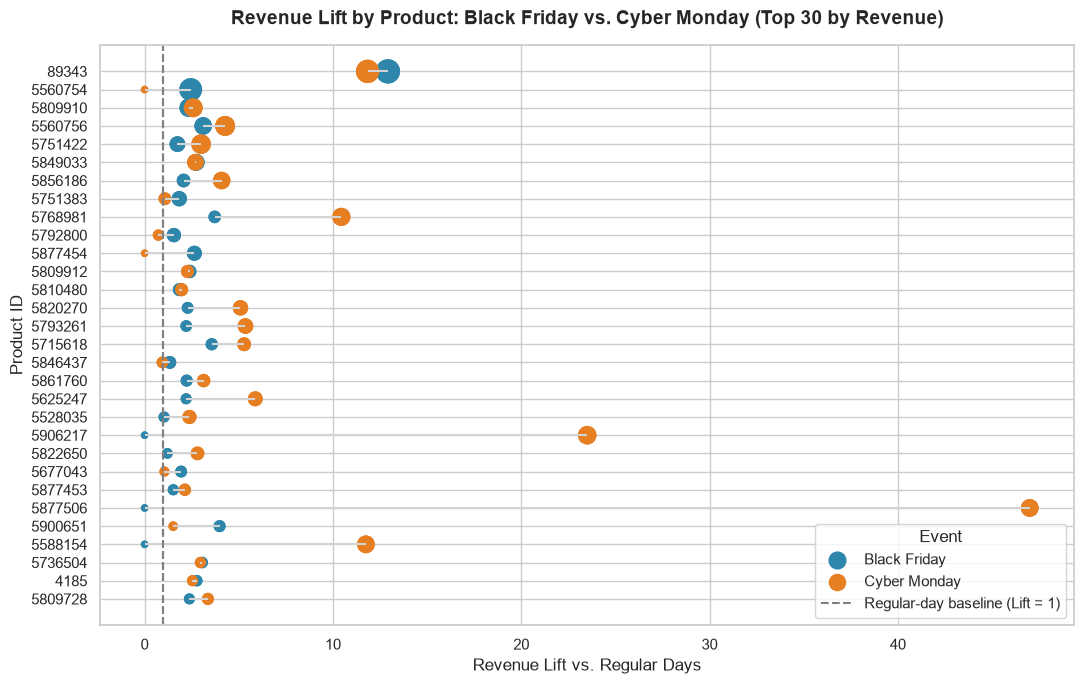

In [ ]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(11, 7))
y_positions = range(len(dumbbell_data))

ax.hlines(
    y_positions,
    dumbbell_data["black_friday_revenue_lift"],
    dumbbell_data["cyber_monday_revenue_lift"],
    color="lightgray",
)
#escala de los puntos
size_scale = 250 / max(
    dumbbell_data["black_friday_avg_daily_revenue"].max(),
    dumbbell_data["cyber_monday_avg_daily_revenue"].max(),
)
ax.scatter(
    dumbbell_data["black_friday_revenue_lift"],
    y_positions,
    s=dumbbell_data["black_friday_avg_daily_revenue"] * size_scale +20,
    color="#2E86AB",
    label="Black Friday",
)
ax.scatter(
    dumbbell_data["cyber_monday_revenue_lift"],
    y_positions,
    s=dumbbell_data["cyber_monday_avg_daily_revenue"] * size_scale +20,
    color="#E67E22",
    label="Cyber Monday",
)
#linea de referencia en x=1
ax.axvline(1, color="gray", linestyle="--")
baseline_line = ax.axvline(1, color="gray", linestyle="--", label="Regular-day baseline (Lift = 1)",)

#Labels de eye Y
ax.set_yticks(y_positions)
ax.set_yticklabels(dumbbell_data["product_id"])

#Titulos
ax.set_title("Revenue Lift by Product: Black Friday vs. Cyber Monday (Top 30 by Revenue)", fontsize=14, fontweight="bold", pad=15)
ax.set(xlabel="Revenue Lift vs. Regular Days", ylabel="Product ID",)

#puntos de la leyenda
black_friday_points = ax.scatter(
    dumbbell_data["black_friday_revenue_lift"],
    y_positions,
    s=dumbbell_data["black_friday_avg_daily_revenue"] * size_scale +20,
    color="#2E86AB",
    label="Black Friday",
)
cyber_monday_points = ax.scatter(
    dumbbell_data["cyber_monday_revenue_lift"],
    y_positions,
    s=dumbbell_data["cyber_monday_avg_daily_revenue"] * size_scale +20,
    color="#E67E22",
    label="Cyber Monday",
)
#leyenda
event_legend = ax.legend(
    handles=[black_friday_points, cyber_monday_points, baseline_line,],
    title="Event",
    loc="lower right",
)

plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "black_friday_vs_cyber_monday_dumbbell.png", dpi=300, bbox_inches="tight")
plt.show()

#### Analisis de temporalidad en productos top revenue 

In [190]:
#Datos para heatmap de analisis de estabilidad de venta en productos del top 30 revenue
top_30_products = product_metrics.nlargest(30, "revenue")["product_id"]

#revenue mensual de los top 30 revenue products
monthly_revenue = (
    df_products_session
    .loc[
        df_products_session["event"].eq("purchase")
        & df_products_session["product_id"].isin(top_30_products)
    ]
    .assign(year_month = lambda data: data["timestamp"].dt.to_period("M").astype(str)) #nueva variable datetime en formato mes
    .groupby(["product_id", "year_month"])["price"]
    .sum()
    .unstack(fill_value=0)
)

In [192]:
#serie temporal del dataset original
month_index = pd.period_range(
    start="2019-10",
    end="2020-02",
    freq="M",
)
#dias de cada mes del dataset original
days_per_month = pd.Series(
    [month.days_in_month for month in month_index],
    index=month_index.astype(str),
    name="days_in_month",
)

In [193]:
#coeficiente de variacion global 
product_cv = (monthly_revenue.std(axis=1) / monthly_revenue.mean(axis=1))

#normalizamos la variacion del revenue y ordenamos por coeficiente de variacion (mas estables primero)
stability_heatmap = (
    monthly_revenue
    .div(monthly_revenue.mean(axis=1), axis=0)
    .loc[product_cv.sort_values().index]
)

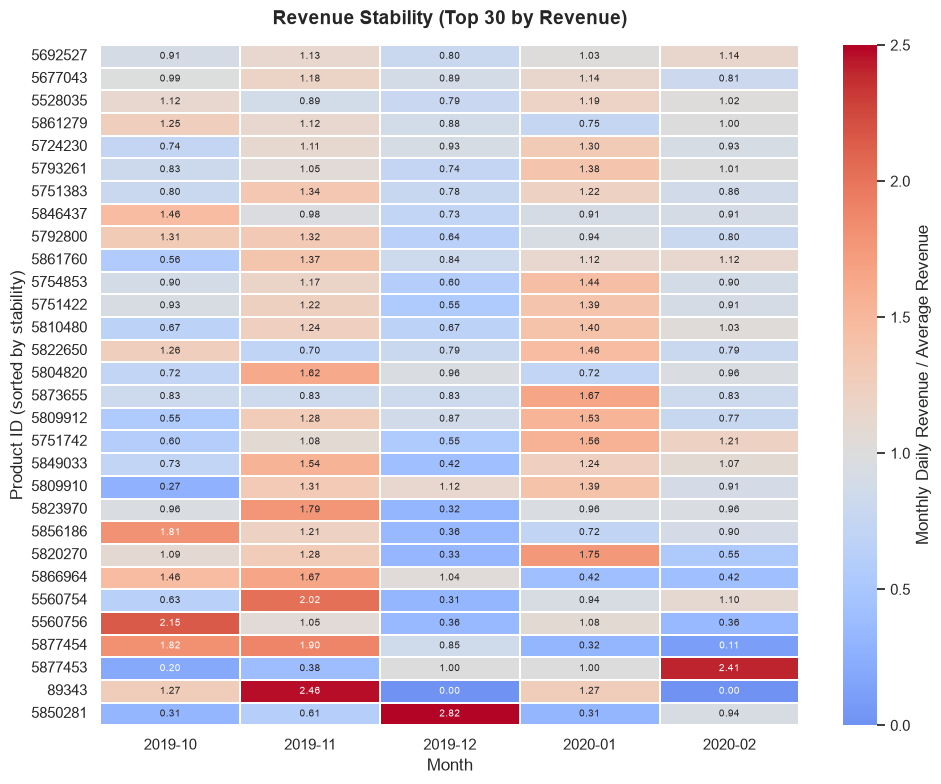

In [195]:
#heatmap de estabilidad de revenue en top 30 revenue products
fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(
    stability_heatmap,
    cmap="coolwarm",
    center=1,
    vmin=0,
    vmax=2.5,
    linewidths=0.2,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={
        "label": "Monthly Daily Revenue / Average Revenue",
    },
    ax=ax,
)
ax.set_title("Revenue Stability (Top 30 by Revenue)", fontsize=14, fontweight="bold", pad=15)
ax.set(xlabel="Month", ylabel="Product ID (sorted by stability)")

plt.tight_layout()
plt.savefig(GRAPHICS_PATH / "top_50_product_revenue_stability_heatmap.png", dpi=300, bbox_inches="tight",)
plt.show()

### Insight 9: Las campañas impulsan productos clave, mientras un núcleo estable sostiene el revenue
- *89343* es el principal producto de campaña: lidera el revenue combinado y el lift en ambos eventos, con picos adicionales en noviembre y enero. Priorizar stock, visibilidad y campañas específicas para este producto en períodos promocionales.

- En Black Friday, los productos *89343, 5560754 y 5560756* combinan mejor revenue y lift. Formar con ellos el catálogo promocional prioritario de Black Friday.

- En Cyber Monday, destacan *5877506, 5906217, 89343, 5588154 y 5768981.* Diseñar una selección propia para Cyber Monday, en lugar de reutilizar automáticamente el catálogo de Black Friday.

- Los productos más estables del top 30 son *5692527, 5677043, 5528035, 5861279 y 5724230.* Mantener pricing, disponibilidad y visibilidad consistentes: sostienen el revenue fuera de campañas.

- Los productos más temporales son *5850281 (2.82x ventas respecto a la media global en diciembre), 89343, 5877453 (2.41x en febrero), 5877454 (1.82x y 1.90x en octubre y noviembre) y 5560756 (2.15x en octubre)*. Ajustar inventario y marketing a sus meses de mayor demanda; no usar su rendimiento puntual como previsión anual.

### Product Category Analysis

In [241]:
#dataset de sesiones analiticas y categorias de productos
category_session = (
    df_products_session.groupby(["analytical_session", "category"], as_index=False)
    .agg(
        has_view=("is_view", "max"),
        has_cart=("is_add_to_cart", "max"),
        has_purchase=("is_purchase", "max"),
        purchase_event_count=("is_purchase", "sum"),
        revenue=("purchase_revenue", "sum"),
    )
)
category_session["is_category_engaged"] = (
    category_session[["has_view", "has_cart", "has_purchase"]]
    .any(axis=1)
)

In [ ]:
#dataset final con metricas de ventas y engagement de categorias de producto
category_metrics = (
    category_session
    .groupby("category", as_index=False)
    .agg(
        engaged_sessions=("is_category_engaged", "sum"),
        view_sessions=("has_view", "sum"),
        cart_sessions=("has_cart", "sum"),
        purchase_sessions=("has_purchase", "sum"),
        purchase_events=("purchase_event_count", "sum"),
        revenue=("revenue", "sum"),
    )
    .assign(
        category_session_purchase_rate=lambda data: (
            data["purchase_sessions"] / data["engaged_sessions"]
        ),
        revenue_per_engaged_session=lambda data: (
            data["revenue"] / data["engaged_sessions"]
        ),
    )
    .replace([float("inf"), float("-inf")], None)
)

#### Category popularity by total engagement sessions

<Axes: ylabel='category'>

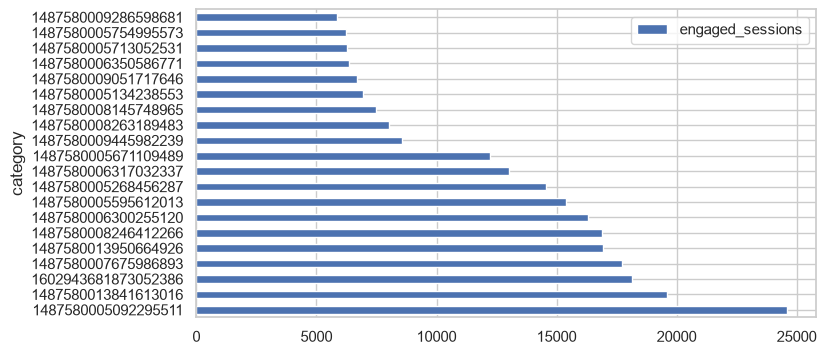

In [67]:
popular_categories = category_metrics[["category", "engaged_sessions"]].sort_values('engaged_sessions', ascending=False).nlargest(20,'engaged_sessions')
    
popular_categories.plot(kind='barh', x='category', y='engaged_sessions',figsize=(8, 4))

#### Category total revenue and purchase session rate

<Axes: ylabel='category'>

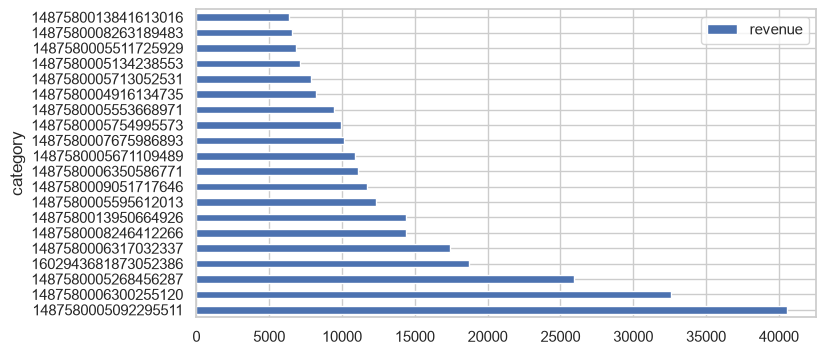

In [73]:
category_revenue = category_metrics[["category", "revenue"]].sort_values('revenue', ascending=False).nlargest(20,'revenue')
category_revenue.plot(kind='barh', x='category', y='revenue',figsize=(8, 4))

Category Purchase rate by session vs Product engagement vs Renevue

In [83]:
category_metrics.revenue.describe(percentiles=[0.75, 0.9, 0.95, 0.99])

count     508.00
mean     1223.52
std      3365.31
min         0.00
75%       865.60
90%      3171.90
95%      5348.09
99%     14387.81
max     40547.66
Name: revenue, dtype: float64

In [98]:
category_metrics.purchase_sessions.describe(percentiles=[0.75, 0.9, 0.95, 0.99])

count    508.00
mean     142.16
std      306.76
min        0.00
75%      132.25
90%      411.90
95%      604.85
99%     1637.00
max     3060.00
Name: purchase_sessions, dtype: float64

In [252]:
#dataset para el scatterplot
plot_data = category_metrics[
    category_metrics["engaged_sessions"].gt(0)
    & category_metrics["revenue"].gt(0)
    & category_metrics["category_session_purchase_rate"].between(0, 1)
].copy()

#filtros de engagement por sesion,purchase sessions y revenue total para evitar purchase rates anomalos
engagement_cutoff = plot_data["engaged_sessions"].quantile(0.75)
revenue_cutoff = plot_data["revenue"].quantile(0.75)
purchases_cutoff = plot_data["purchase_sessions"].quantile(0.75)

#aplicamos filtros
plot_data = plot_data[
    (plot_data["engaged_sessions"] >= engagement_cutoff)
    & (plot_data["revenue"] >= revenue_cutoff)
    & (plot_data["purchase_sessions"] >= purchases_cutoff)
]

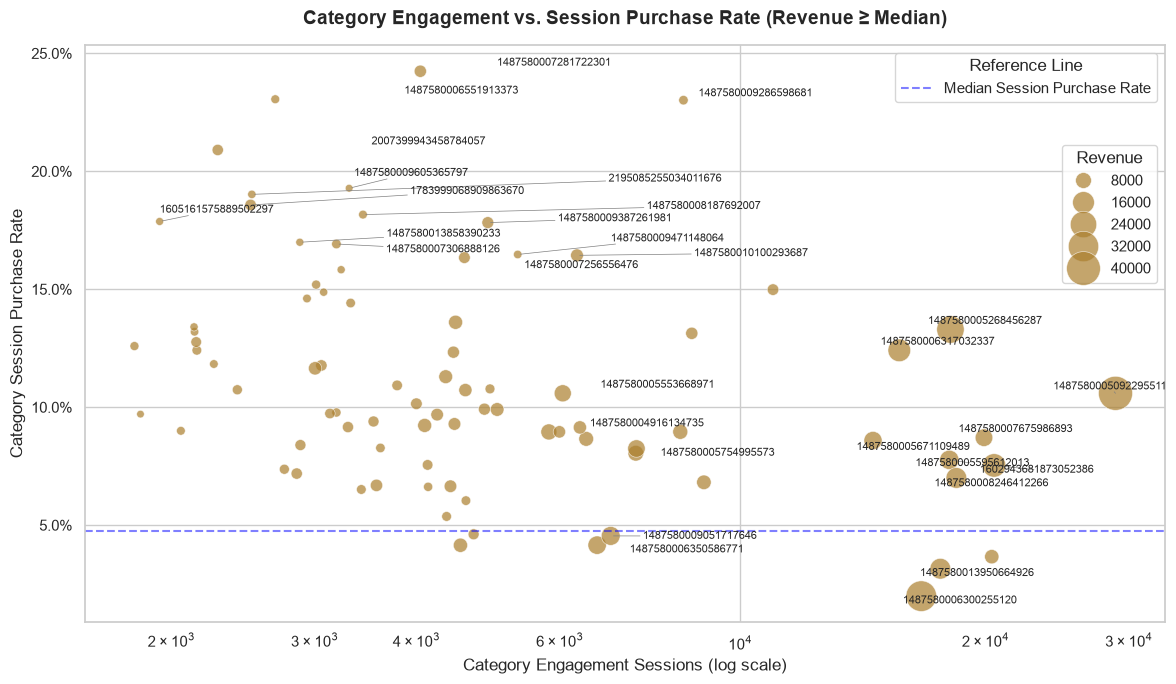

In [253]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=plot_data,
    x="engaged_sessions",
    y="category_session_purchase_rate",
    size="revenue",
    sizes=(30, 600),
    alpha=0.7,
    color="#AB7F2E",
    legend="brief",
    ax=ax,
)

#titulos
ax.set_title("Category Engagement vs. Session Purchase Rate (Revenue ≥ Median)", fontsize=14, fontweight="bold", pad=15)
ax.set(xlabel="Category Engagement Sessions (log scale)", ylabel="Category Session Purchase Rate",)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.get_legend().set_title("Revenue")

#Categorias con label en el scatter
from adjustText import adjust_text

labels = (pd.concat([plot_data.nlargest(15, "revenue"),plot_data.nlargest(15, "category_session_purchase_rate"),])
.drop_duplicates("category"))

texts = []
for category, engagement, purchase_rate in zip(
    labels["category"],
    labels["engaged_sessions"],
    labels["category_session_purchase_rate"],
):
    texts.append(ax.text(engagement, purchase_rate, str(category).removesuffix(".0"), fontsize=8,))

adjust_text(texts, ax=ax, arrowprops= {"arrowstyle": "-", "color": "gray", "linewidth": 0.5,},)

#lineas de la leyenda
rate_cutoff = plot_data.category_session_purchase_rate.std()
rate_line = ax.axhline(rate_cutoff, color="blue", alpha=0.5, linestyle="--", label="Median Session Purchase Rate")

#leyendas
revenue_legend = ax.get_legend()
revenue_legend.set_bbox_to_anchor((1, 0.84),transform=ax.transAxes,)
revenue_legend.set_title("Revenue")
ax.add_artist(revenue_legend)

ax.legend(handles=[rate_line], title="Reference Line", loc="upper right",)

#escala del eje X logaritmica
ax.set_xscale("log")

plt.tight_layout()
plt.savefig( GRAPHICS_PATH / "category_engagement_vs_purchase_rate.png", dpi=300, bbox_inches="tight",)
plt.show()

In [255]:
plot_data.sort_values(by='category_session_purchase_rate',ascending=False).head(10)

,category,engaged_sessions,view_sessions,cart_sessions,purchase_sessions,purchase_events,revenue,category_session_purchase_rate,revenue_per_engaged_session
85,1487580007281722301,4047,1949,2113,981,1022,4389.96,0.24,1.08
60,1487580006551913373,2685,1447,1348,619,675,1812.80,0.23,0.68
158,1487580009286598681,8517,4223,4769,1960,3328,2220.67,0.23,0.26
439,2007399943458784057,2282,1336,1128,477,528,3555.37,0.21,1.56
169,1487580009605365797,3309,1810,1679,638,772,1161.08,0.19,0.35
495,2195085255034011676,2513,1450,1149,478,506,1505.56,0.19,0.60
374,1783999068909863670,2504,1652,1155,465,674,3732.73,0.19,1.49
121,1487580008187692007,3441,1973,1715,625,811,1762.12,0.18,0.51
344,1605161575889502297,1936,972,1049,346,364,1295.06,0.18,0.67
162,1487580009387261981,4898,3090,2145,873,956,4061.48,0.18,0.83


In [256]:
plot_data.sort_values(by='revenue',ascending=False).head(10)

,category,engaged_sessions,view_sessions,cart_sessions,purchase_sessions,purchase_events,revenue,category_session_purchase_rate,revenue_per_engaged_session
12,1487580005092295511,28903,22438,10083,3060,4416,40547.66,0.11,1.40
51,1487580006300255120,16687,16155,1467,332,348,32576.45,0.02,1.95
15,1487580005268456287,18123,12695,6987,2409,3021,25962.73,0.13,1.43
341,1602943681873052386,20503,17197,5709,1544,3637,18720.33,0.08,0.91
52,1487580006317032337,15681,11673,6209,1946,4850,17397.78,0.12,1.11
124,1487580008246412266,18428,16133,4275,1290,1680,14388.82,0.07,0.78
317,1487580013950664926,17612,16618,2144,555,645,14374.37,0.03,0.82
29,1487580005595612013,18065,14486,6204,1403,4065,12311.78,0.08,0.68
150,1487580009051717646,6933,6509,1063,315,318,11734.42,0.05,1.69
53,1487580006350586771,6672,6181,1041,277,311,11113.27,0.04,1.67


### Insight 10: Product category performance overview

- **Top revenue**: la categoria *1487580005092295511* es la mas popular (24592 engaged sessions) y con mas revenue total (40547.66).

- **Top performance (revenue + purchase rate)**:las categoria que tiene mejor purchase rate por sesion y mas revenue combinado es la *1487580005268456287* (25962.73 revenue y 17% purchase rate) y la *1487580006317032337* (17397.78 revenue y 15% purchase rate).

- **Top conversion**: las categorias *1487580009387261981, 1487580010100293687, 1487580009445982239, 1487580009445982239 yu 1487580005268456287* ocupan el top 5 de categorias con mayor tasa de ventas por sesion, aunque su revenue total se encuentra un poco por debajo de la mediana. Crear campañas publicitarias especificas para estos productos podria aumentar mucho el revenue total si la tasa de conversión se mantiene.

- **Gigantes dormidos(revenue)**: las categorias con mas revenue pero purchase rate mas bajo son la *1487580006300255120* (32576.4 revenue y 2% de purchase rate) y la *1487580013950664926* (14374.37 de revenue y 3% purchase rate).

#### Análisis aislado de categorias *1487580006300255120* y *1487580013950664926* (alto revenue, bajo PR)

Precio de productos dentro de categoria

In [261]:
#Analisis de categorias con mas revenue y menor PR
metricas_A = (df_products_session.loc[df_products_session.category.eq(1487580006300255120)]
.groupby('product_id')
.agg(product_price = ('price', 'mean'))
.product_price.std())
metricas_B = (df_products_session.loc[df_products_session.category.eq(1487580013950664926)]
.groupby('product_id')
.agg(product_price = ('price', 'mean'))
.product_price.std())
metricas_C = (df_products_session.loc[df_products_session.category.eq(1487580005092295511)]
.groupby('product_id')
.agg(product_price = ('price', 'mean'))
.product_price.std())
metricas_D = (df_products_session.loc[df_products_session.category.eq(1487580005268456287)]
.groupby('product_id')
.agg(product_price = ('price', 'mean'))
.product_price.std())

product_metrics['precio_medio'] = product_metrics['revenue'] / product_metrics['purchase_events']
metricas_global = product_metrics.precio_medio.std()

print(f"Metricas de precio de productos de categoria PR muy bajo 1487580006300255120: {metricas_A}")
print(f"Metricas de precio de productos de categoria PR muy bajo 1487580013950664926: {metricas_B}")
print(f"Metricas de precio de productos de categoria PR medio-alto 1487580006300255120: {metricas_C}")
print(f"Metricas de precio de productos de categoria PR medio-alto 1487580013950664926: {metricas_D}")
print(f"Metricas de precio de productos global: {metricas_global}")

Metricas de precio de productos de categoria PR muy bajo 1487580006300255120: 67.4986708265192
Metricas de precio de productos de categoria PR muy bajo 1487580013950664926: 20.630960617891024
Metricas de precio de productos de categoria PR medio-alto 1487580006300255120: 6.443334138365733
Metricas de precio de productos de categoria PR medio-alto 1487580013950664926: 6.036427406140554
Metricas de precio de productos global: 9.55660420847421


Revenue per engaged session

In [250]:
category_metrics.query('category == 1487580006300255120 or category == 1487580013950664926')[['category','revenue_per_engaged_session']]

,category,revenue_per_engaged_session
51,1487580006300255120,1.95
317,1487580013950664926,0.82


In [262]:
category_metrics.revenue_per_engaged_session.std()

np.float64(0.4616354869711213)

#### Insight 10.1 : Precio mediano de productos elevado podria afectar al PR de algunas categorias
- Las categorias *1487580006300255120 y 1487580013950664926* presentan PR muy bajos (2% y 3% resp.) teniendo en cuenta su elevado revenue total. Comparando con otras categorias de producto con revenue parecido como la *1487580006300255120 y 1487580013950664926* (11% y 13% resp.) la única diferencia apreciable observada se encuentra en el precio de los productos (las categorias con bajo PR tienen el precio mediano de sus productos mucho mas elevados que la medianas de categorias con PR mas elevados y de la mediana global). Esto puede sugerir que invertir mas en publicidad para éstas categorias no necesariamente puede aumentar su conversión ya que su naturaleza puede ser completamente distinta (al no disponer de información sobre las categorias mas allá de su numero de identificasción no se ha podido comparar la naturaleza de las mismas). 

In [ ]:
#Exportamos dataset final a nivel evento con sesiones analiticas para uso futuro en el recomendador de productos
df_event_session.drop(columns=['user_session', 'gap_minutes', 'new_session', 'analytical_session_number'], inplace=True)
order=['timestamp', 'user_id', 'analytical_session', 'event', 'product_id',
       'category', 'price', 'date', 'year', 'month', 'day', 'day_of_week',
       'hour', 'holiday', 'is_unity_day', 'is_singles_day', 'is_black_friday',
       'is_cyber_monday', 'is_new_year_period', 'is_orthodox_christmas',
       'is_valentines_day', 'is_defender_day', 'is_add_to_cart',
       'is_remove_from_cart', 'is_purchase', 'is_view']
df_event_session = df_event_session[order]

In [271]:
df_event_session.to_parquet("../data/processed/df_event_session_final.parquet", index=True)
product_metrics.to_parquet("../data/processed/product_metrics.parquet", index=True)